In [248]:
# ============================================
# 1. Импорт библиотек + отключение предупреждений
# ============================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter
import networkx as nx

plt.style.use("seaborn-v0_8")


In [249]:
# ============================================
# 2. Загрузка данных
# ============================================

df = pd.read_csv("/content/cheki.csv")
df.head()


,Фамилия_Номер_покупки,Продукт,Стоимость,Тип,Время покупки
0,Байдаков_1,Сидр,275,Алкоголь,3:45
1,Байдаков_1,Сигареты,102,Сигареты,3:46
2,Байдаков_2,Пиво,730,Алкоголь,23:20
3,Байдаков_2,Чипсы,132,Фастфуд,23:21
4,Байдаков_2,Сухарики,90,Фастфуд,23:22


In [250]:
# ============================================
# 2. Подготовка данных
# ============================================
df[['Фамилия', 'Номер_покупки']] = df['Фамилия_Номер_покупки'].str.split('_', expand=True)
df['Номер_покупки'] = df['Номер_покупки'].astype(int)
df = df.drop('Фамилия_Номер_покупки', axis=1)


df = df.rename(columns={
    'Фамилия': 'name',
    'Номер_покупки': 'transaction_number',
    'Продукт': 'product',
    'Стоимость': 'price',
    'Тип': 'category',
    'Время покупки': 'time'
})

df.head()

,product,price,category,time,name,transaction_number
0,Сидр,275,Алкоголь,3:45,Байдаков,1
1,Сигареты,102,Сигареты,3:46,Байдаков,1
2,Пиво,730,Алкоголь,23:20,Байдаков,2
3,Чипсы,132,Фастфуд,23:21,Байдаков,2
4,Сухарики,90,Фастфуд,23:22,Байдаков,2


In [251]:
# ============================================
# 4. Формирование корзин (по name + transaction_number)
# ============================================

basket = df.groupby(["name", "transaction_number"])["product"].apply(list)


In [252]:
# ============================================
# 5. Подсчёт совместных покупок (co-occurrence)
# ============================================

pairs = Counter()

for items in basket:
    unique_items = set(items)
    for a, b in combinations(sorted(unique_items), 2):
        pairs[(a, b)] += 1

pd.Series(pairs).sort_values(ascending=False)
pass


In [253]:
# ============================================
# 6. Матрица совместных покупок
# ============================================

items = sorted(df["product"].unique())
matrix = pd.DataFrame(0, index=items, columns=items)

for (a, b), count in pairs.items():
    matrix.loc[a, b] = count
    matrix.loc[b, a] = count




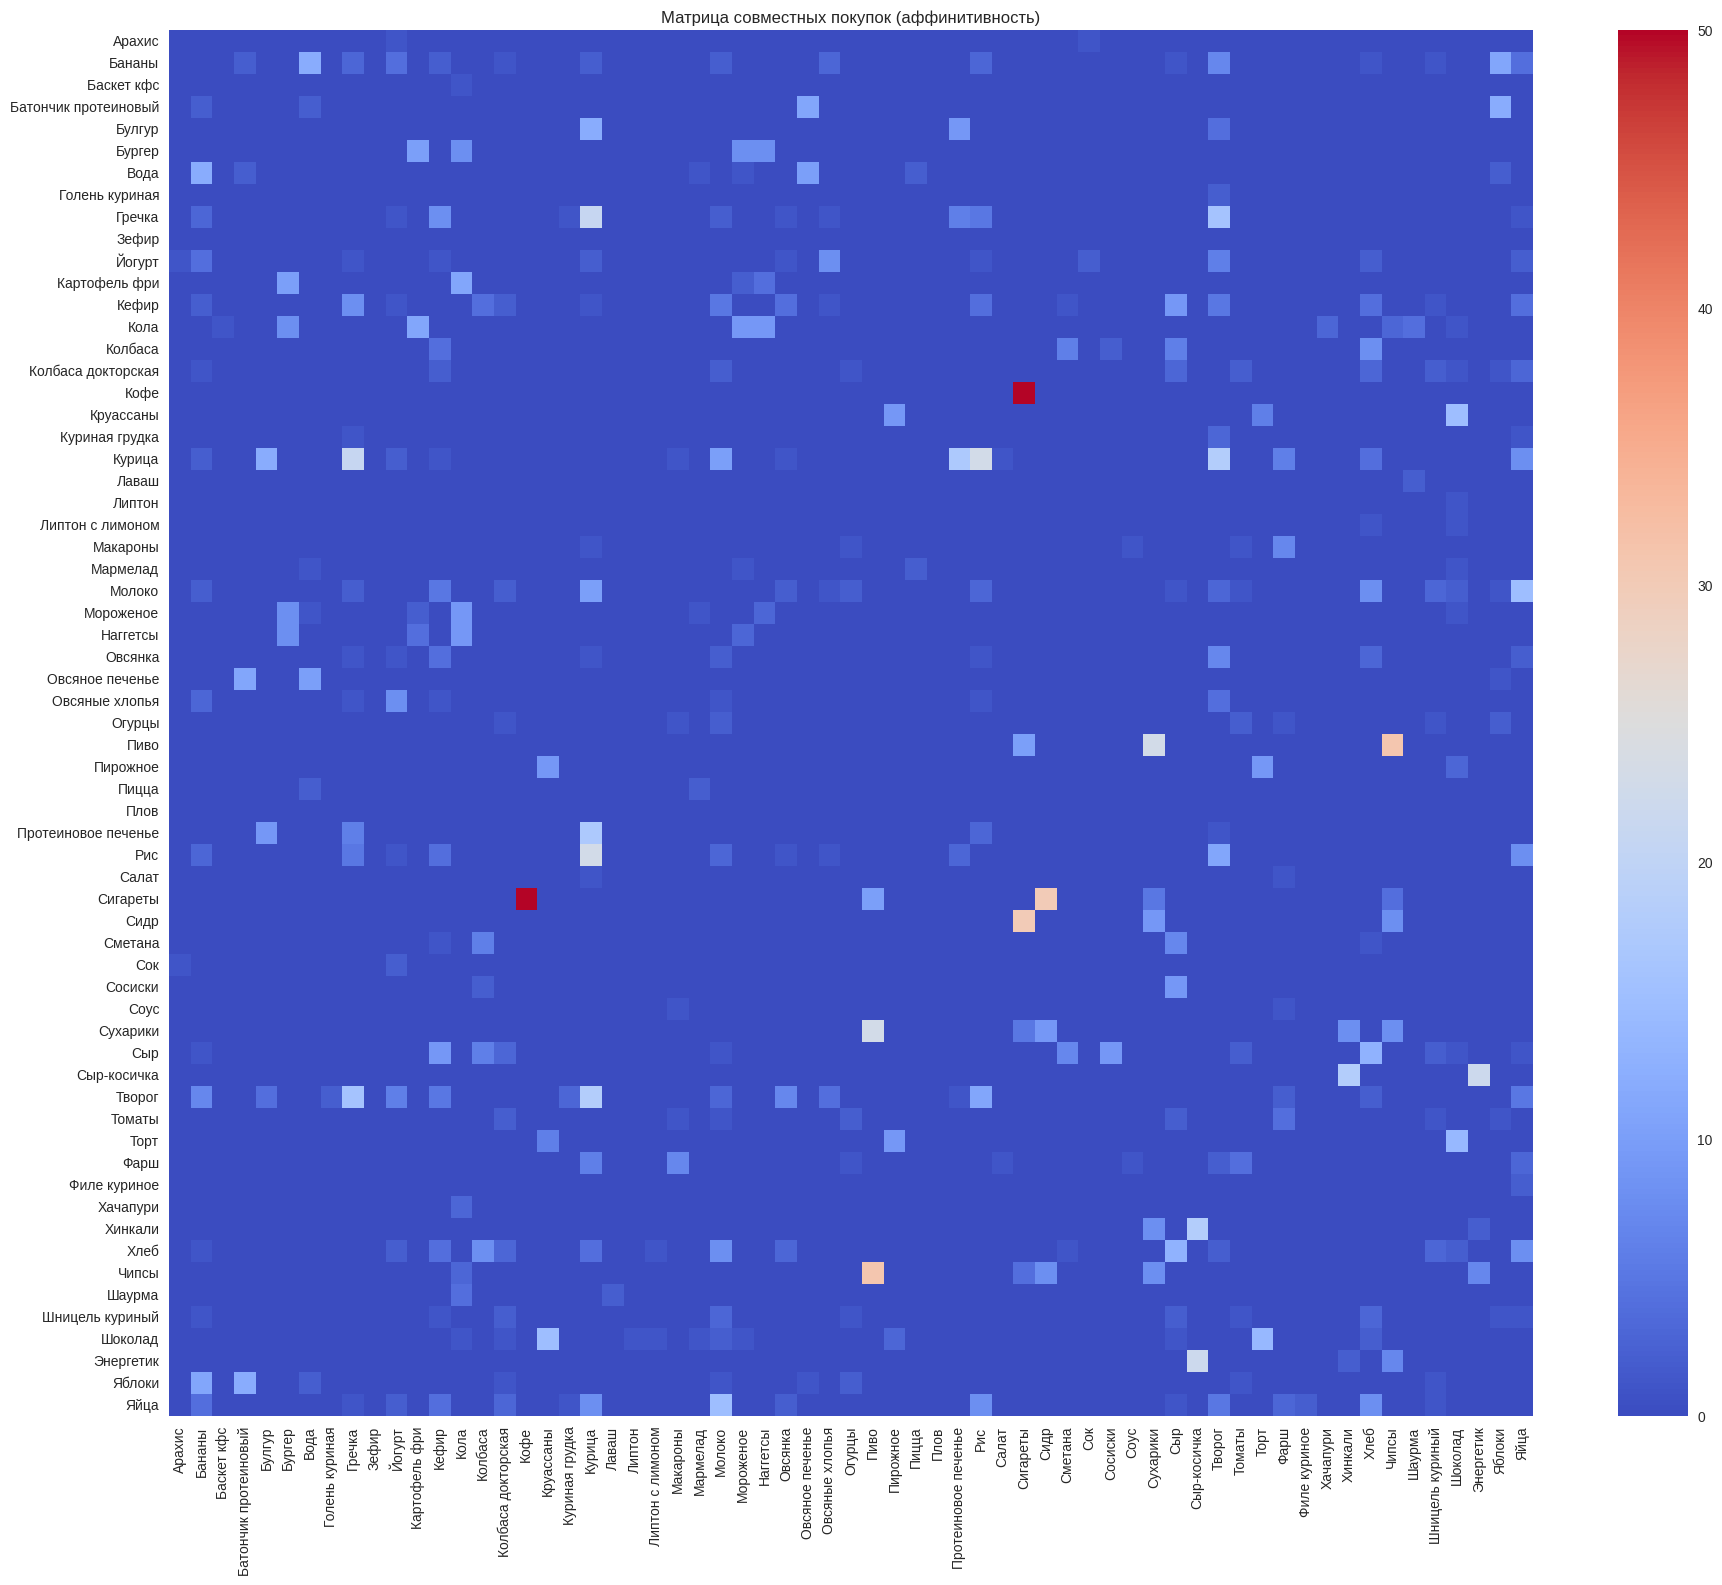

In [254]:
# ============================================
# 7. Heatmap совместных покупок
# ============================================

plt.figure(figsize=(22, 18))
sns.heatmap(matrix, cmap="coolwarm")
plt.title("Матрица совместных покупок (аффинитивность)")
plt.show()


In [255]:
# ============================================
# 8. Нормализованная аффинитивность (коэффициент Жаккара)
# ============================================

jaccard = pd.DataFrame(0.0, index=items, columns=items)

for a in items:
    for b in items:
        if a == b:
            continue
        inter = matrix.loc[a, b]
        union = (
            (df["product"] == a).sum() +
            (df["product"] == b).sum() -
            inter
        )
        jaccard.loc[a, b] = inter / union if union > 0 else 0



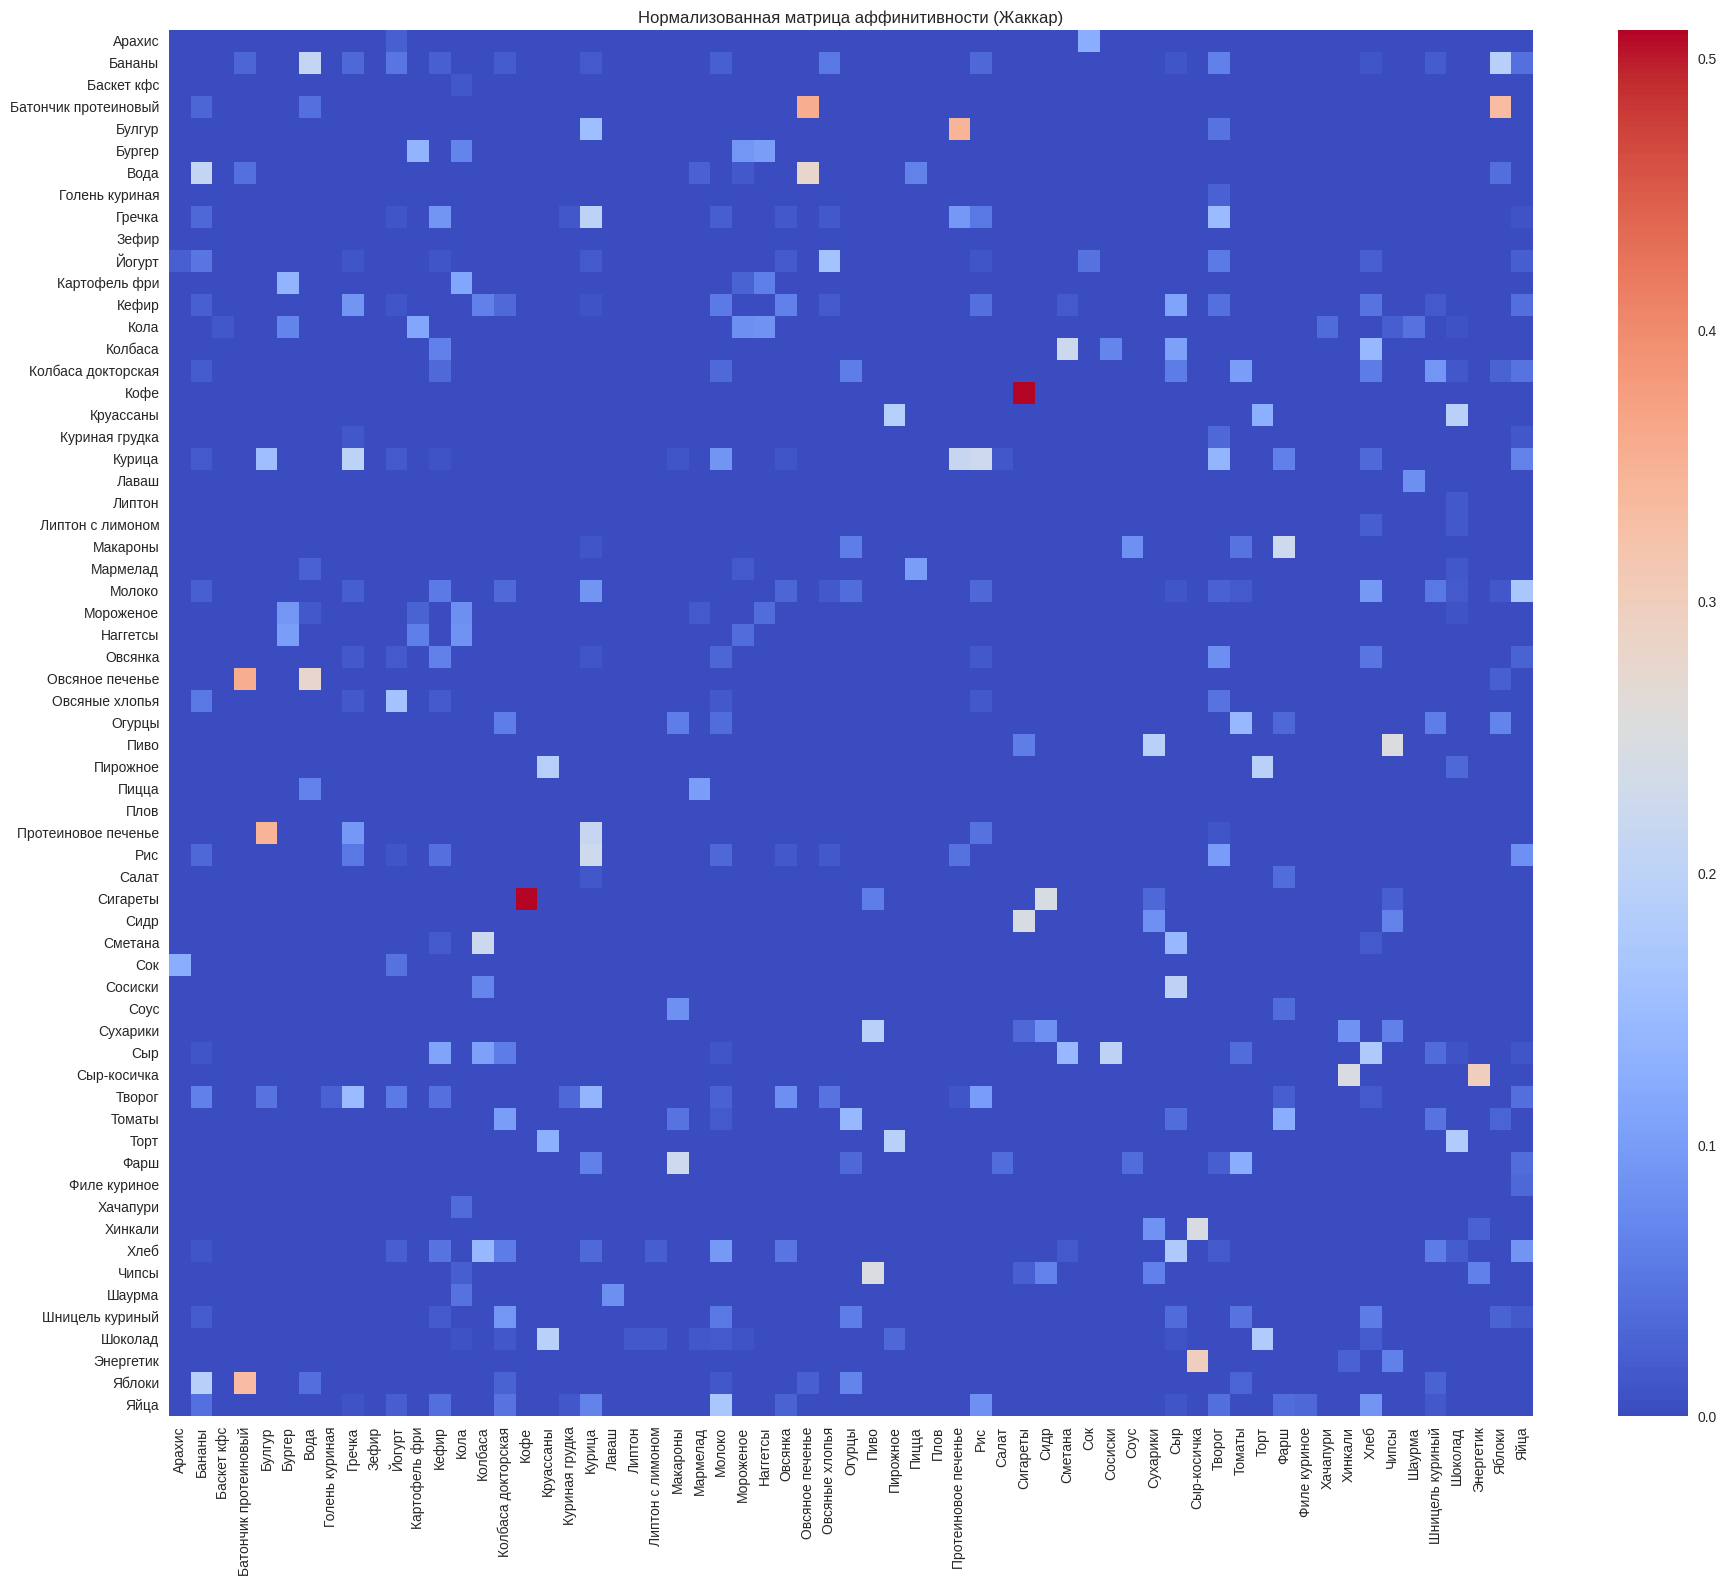

In [256]:
# ============================================
# 9. Heatmap нормализованной матрицы Жаккара
# ============================================

plt.figure(figsize=(22, 18))
sns.heatmap(jaccard, cmap="coolwarm")
plt.title("Нормализованная матрица аффинитивности (Жаккар)")
plt.show()


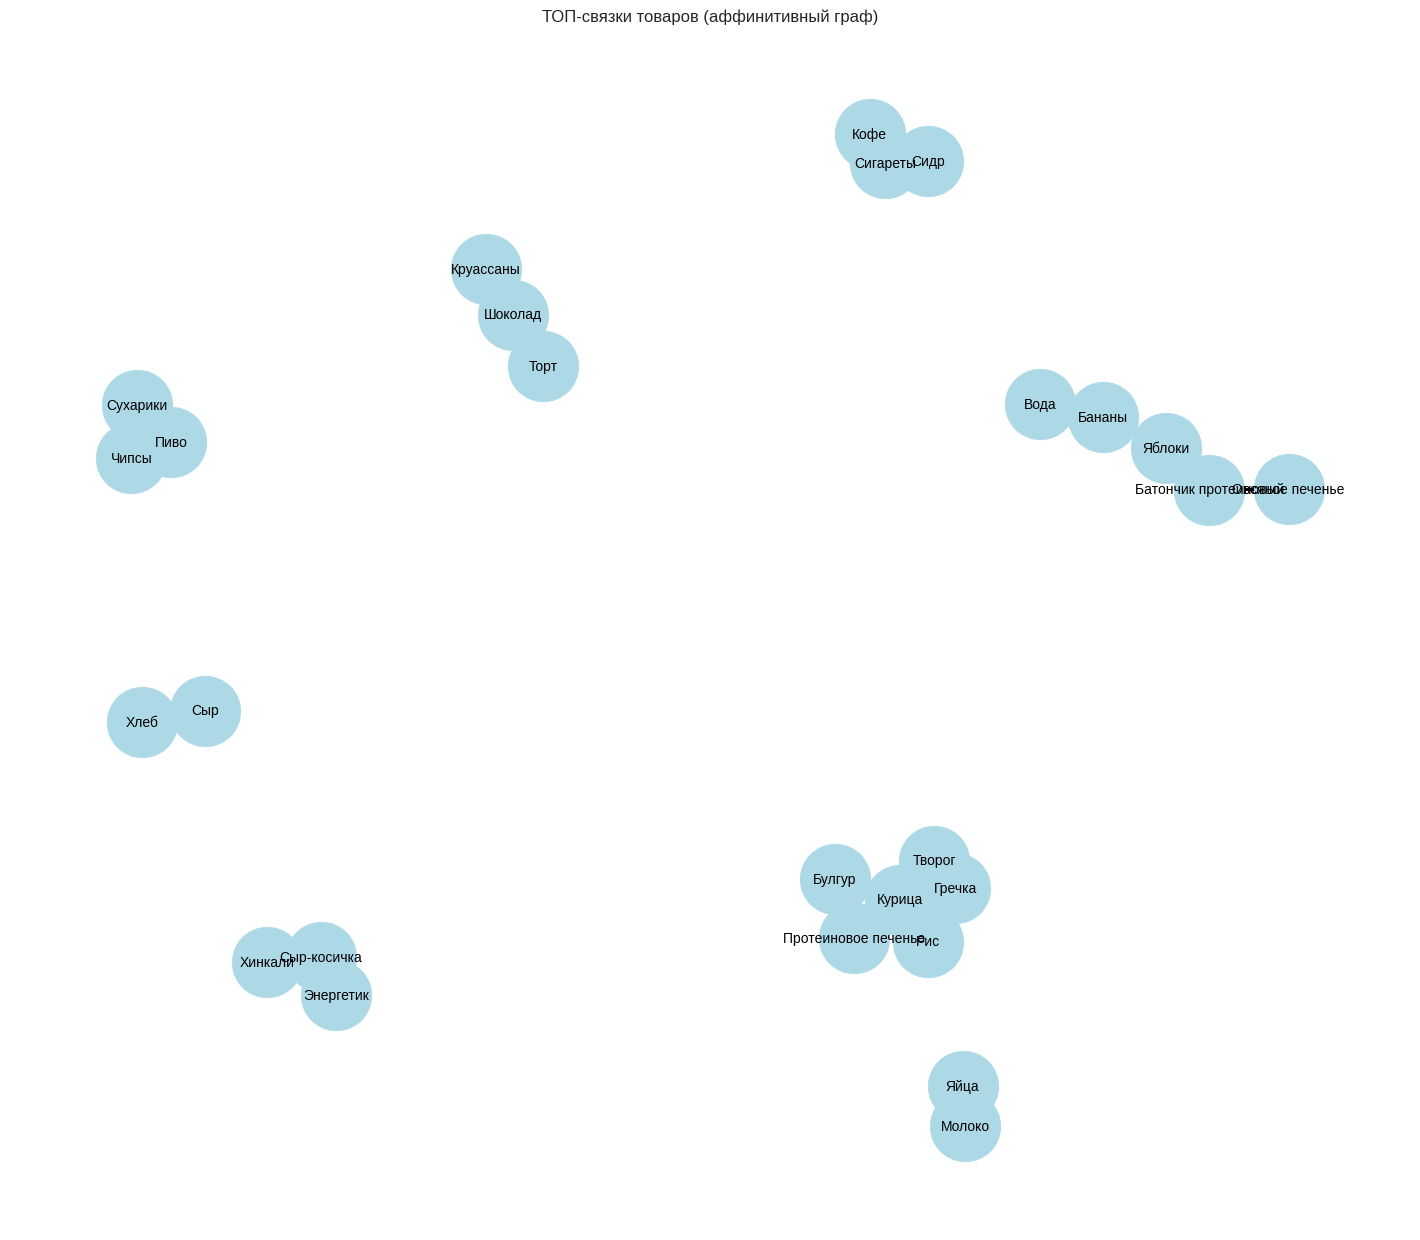

In [257]:
# ============================================
# 10. ТОП‑связки (графовая визуализация)
# ============================================

top_pairs = pd.Series(pairs).sort_values(ascending=False).head(20)

G = nx.Graph()

for (a, b), w in top_pairs.items():
    G.add_edge(a, b, weight=w)

plt.figure(figsize=(14, 12))
pos = nx.spring_layout(G, k=0.5, seed=42)

nx.draw(
    G, pos,
    with_labels=True,
    node_size=2600,
    node_color="lightblue",
    font_size=10,
    width=[G[u][v]['weight'] / 5 for u, v in G.edges()]
)

plt.title("ТОП‑связки товаров (аффинитивный граф)")
plt.show()


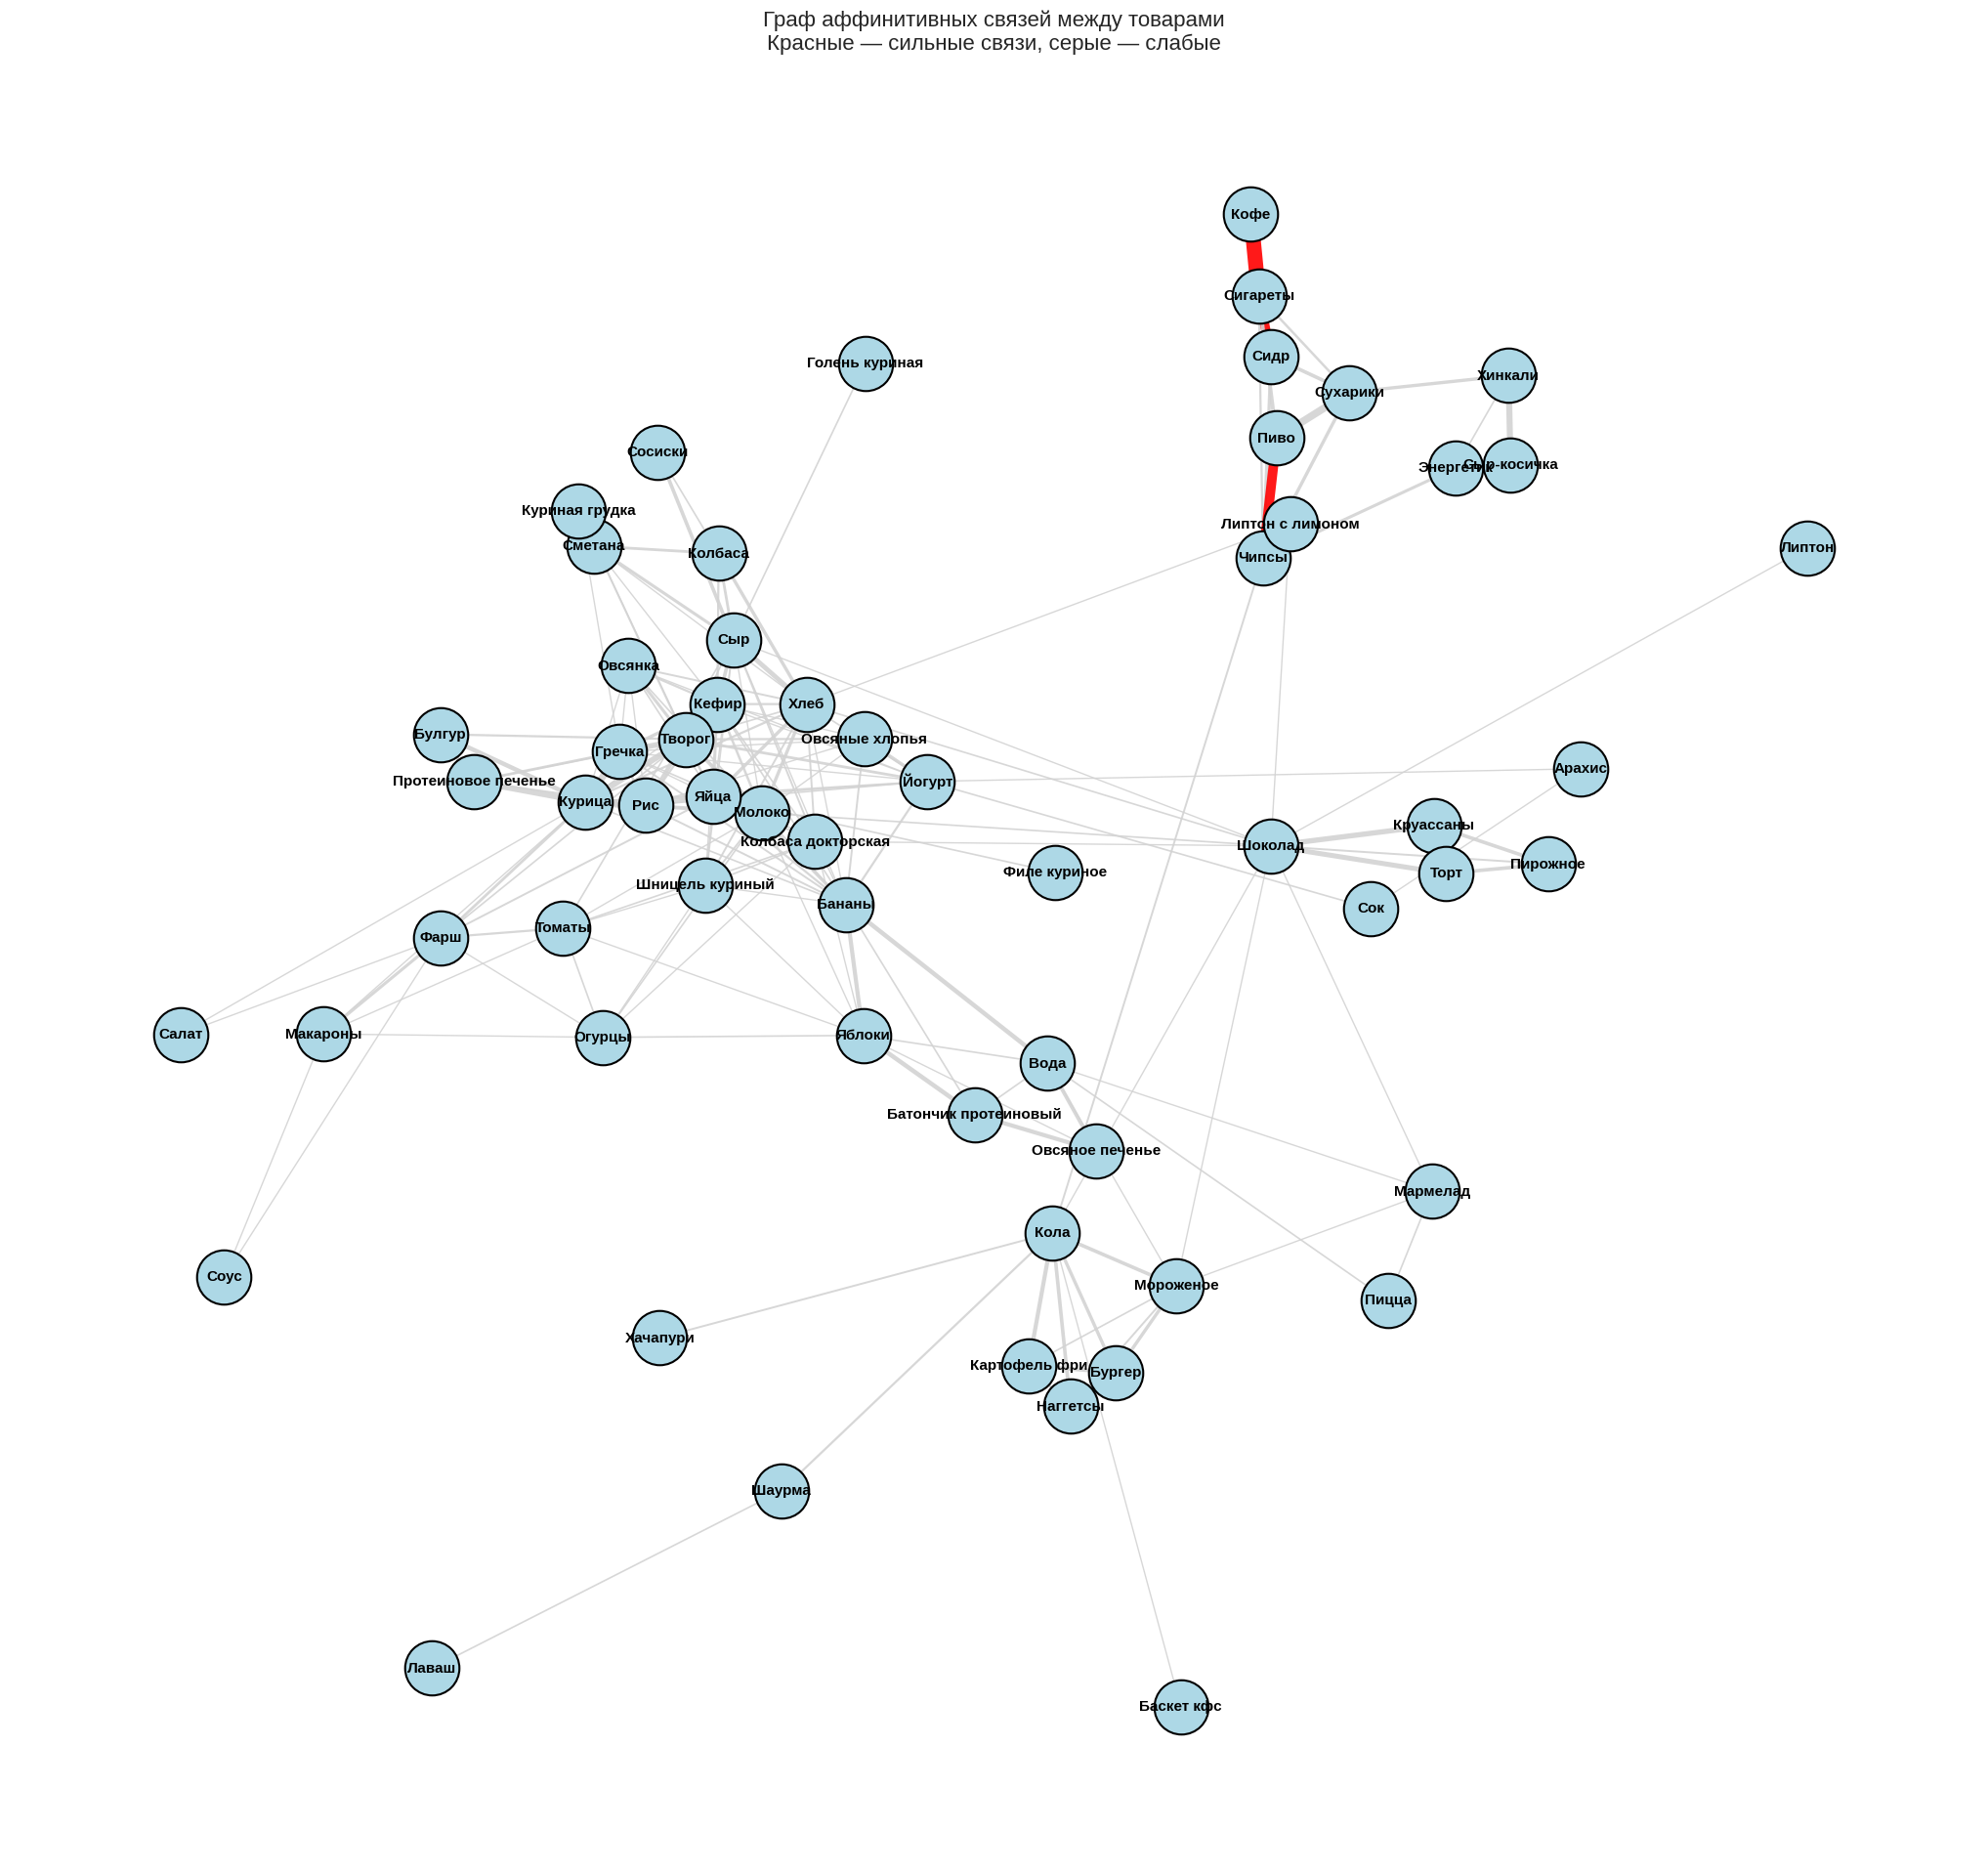

In [258]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Создаём граф
G = nx.Graph()

for (a, b), w in pairs.items():
    G.add_edge(a, b, weight=w)

# Позиции узлов — увеличим отталкивание
plt.figure(figsize=(26, 24))
pos = nx.spring_layout(G, k=0.6, iterations=80, seed=42)

# Веса рёбер
weights = np.array([G[u][v]['weight'] for u, v in G.edges()])
max_w = weights.max()
min_w = weights.min()

# Толщина рёбер
edge_widths = 1 + 10 * (weights - min_w) / (max_w - min_w)

# Цвета: только красный и серый
edge_colors = ["red" if w > max_w * 0.5 else "lightgray" for w in weights]

# Узлы
nx.draw_networkx_nodes(
    G, pos,
    node_size=1600,
    node_color="lightblue",
    edgecolors="black",
    linewidths=1.5
)

# Подписи
nx.draw_networkx_labels(
    G, pos,
    font_size=11,
    font_weight="bold"
)

# Рёбра
nx.draw_networkx_edges(
    G, pos,
    width=edge_widths,
    edge_color=edge_colors,
    alpha=0.9
)

plt.title("Граф аффинитивных связей между товарами\nКрасные — сильные связи, серые — слабые", fontsize=16)
plt.axis("off")
plt.show()


In [259]:
# ============================================
# 11. Анализ по категориям
# ============================================

basket_types = df.groupby(["name", "transaction_number"])["category"].apply(list)

pairs_types = Counter()

for items in basket_types:
    unique_items = set(items)
    for a, b in combinations(sorted(unique_items), 2):
        pairs_types[(a, b)] += 1

pd.Series(pairs_types).sort_values(ascending=False)
pass


In [260]:
# ============================================
# 12. Матрица категорий
# ============================================

types = sorted(df["category"].unique())
matrix_types = pd.DataFrame(0, index=types, columns=types)

for (a, b), count in pairs_types.items():
    matrix_types.loc[a, b] = count
    matrix_types.loc[b, a] = count



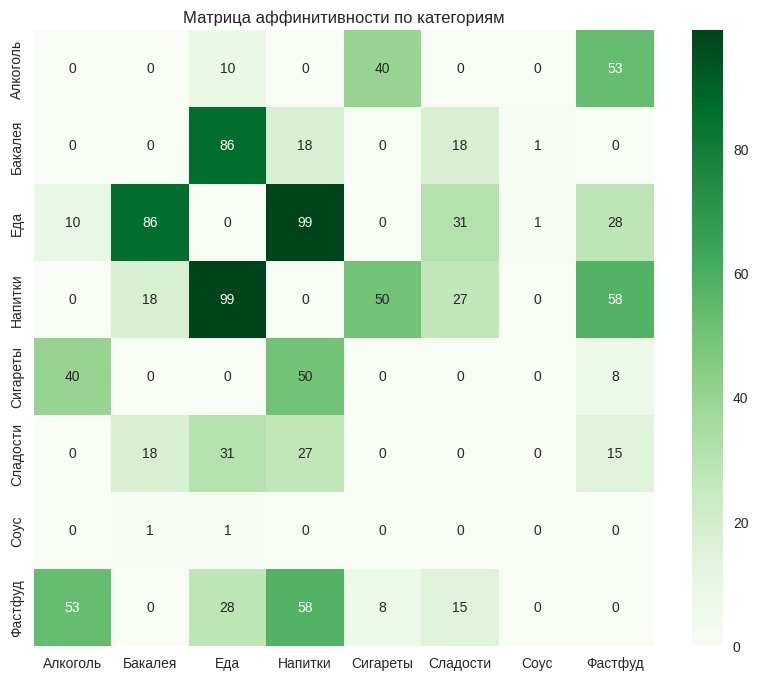

In [261]:
# ============================================
# 13. Heatmap категорий
# ============================================

plt.figure(figsize=(10, 8))
sns.heatmap(matrix_types, annot=True, cmap="Greens")
plt.title("Матрица аффинитивности по категориям")
plt.show()


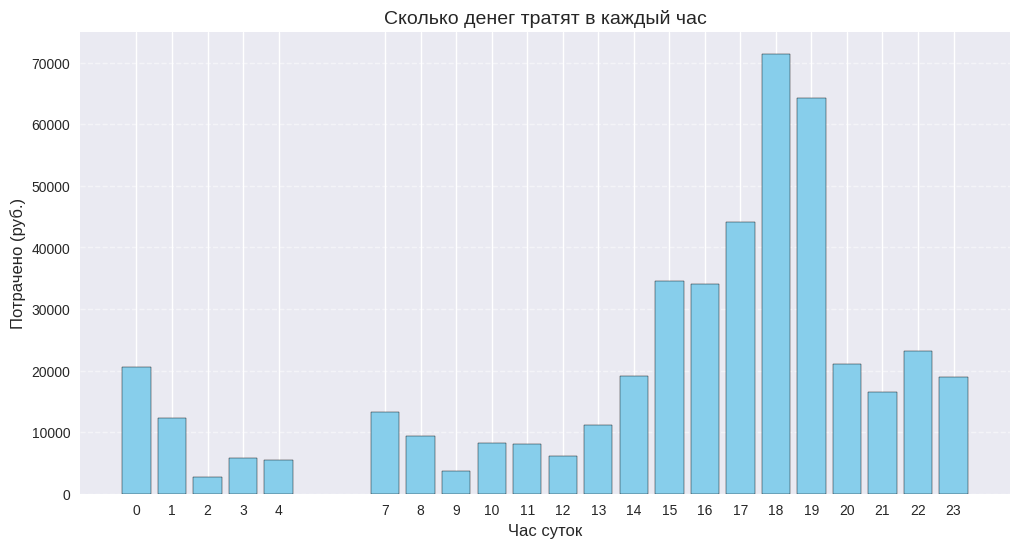

In [262]:
# ============================================
# Сумма покупок по часам
# ============================================

# Преобразуем время в datetime
df['time'] = pd.to_datetime(df['time'], format='%H:%M')

# Выделяем час
df['hour'] = df['time'].dt.hour

# Группируем по часу и считаем сумму
spending_by_hour = df.groupby('hour')['price'].sum().reset_index()

# Переименуем для красоты
spending_by_hour.columns = ['Час', 'Потрачено_руб']

spending_by_hour
# ============================================
# Гистограмма трат по часам
# ============================================

plt.figure(figsize=(12, 6))

plt.bar(
    spending_by_hour['Час'],
    spending_by_hour['Потрачено_руб'],
    color='skyblue',
    edgecolor='black'
)

plt.xlabel("Час суток", fontsize=12)
plt.ylabel("Потрачено (руб.)", fontsize=12)
plt.title("Сколько денег тратят в каждый час", fontsize=14)

plt.xticks(spending_by_hour['Час'])  # чтобы были все часы
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()



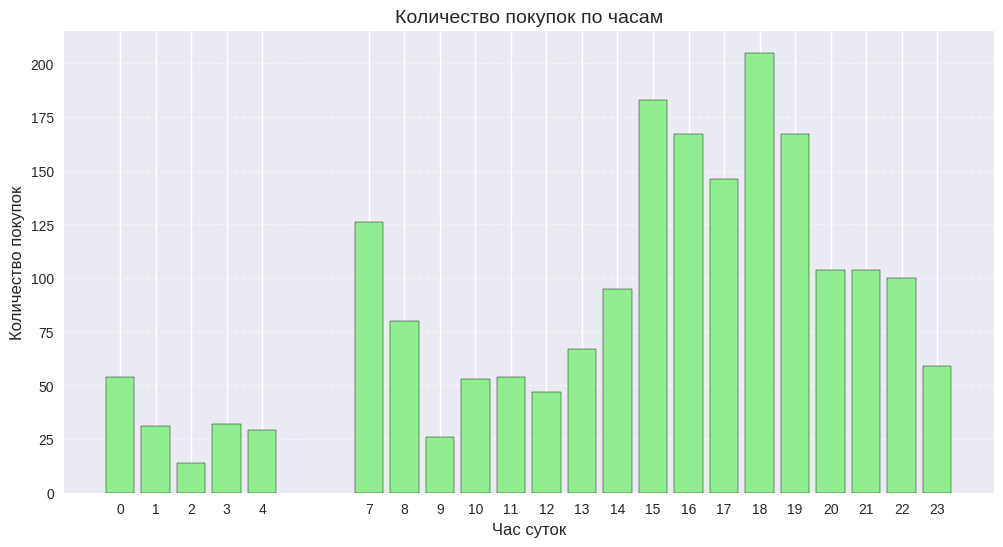

In [263]:
# ============================================
# Количество покупок по часам
# ============================================

# Если ещё не выделяли час — выделим
df['time'] = pd.to_datetime(df['time'], format='%H:%M')
df['hour'] = df['time'].dt.hour

# Группировка: количество строк (покупок) в каждый час
count_by_hour = df.groupby('hour')['product'].count().reset_index()
count_by_hour.columns = ['Час', 'Количество_покупок']

count_by_hour

plt.figure(figsize=(12, 6))

plt.bar(
    count_by_hour['Час'],
    count_by_hour['Количество_покупок'],
    color='lightgreen',
    edgecolor='black'
)

plt.xlabel("Час суток", fontsize=12)
plt.ylabel("Количество покупок", fontsize=12)
plt.title("Количество покупок по часам", fontsize=14)

plt.xticks(count_by_hour['Час'])
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

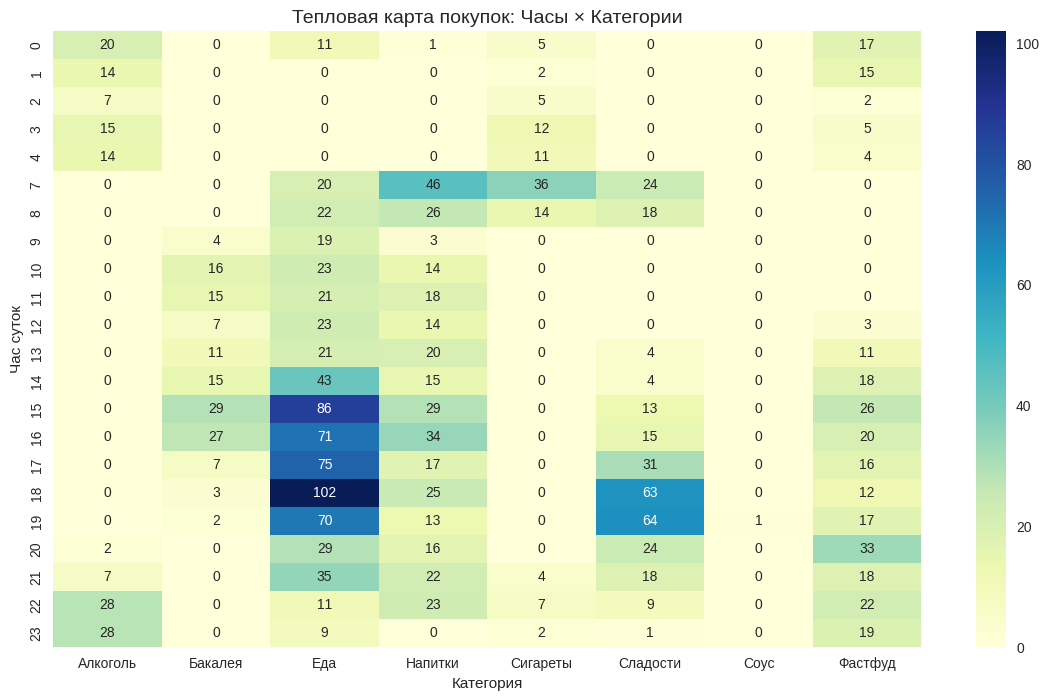

In [264]:

# ============================================
# Тепловая карта: Часы × Категории
# ============================================

# Убедимся, что есть hour
df['time'] = pd.to_datetime(df['time'], format='%H:%M')
df['hour'] = df['time'].dt.hour

# Группировка: сколько покупок каждой категории в каждый час
heat = df.groupby(['hour', 'category']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(heat, cmap="YlGnBu", annot=True, fmt="d")

plt.title("Тепловая карта покупок: Часы × Категории", fontsize=14)
plt.xlabel("Категория")
plt.ylabel("Час суток")

plt.show()


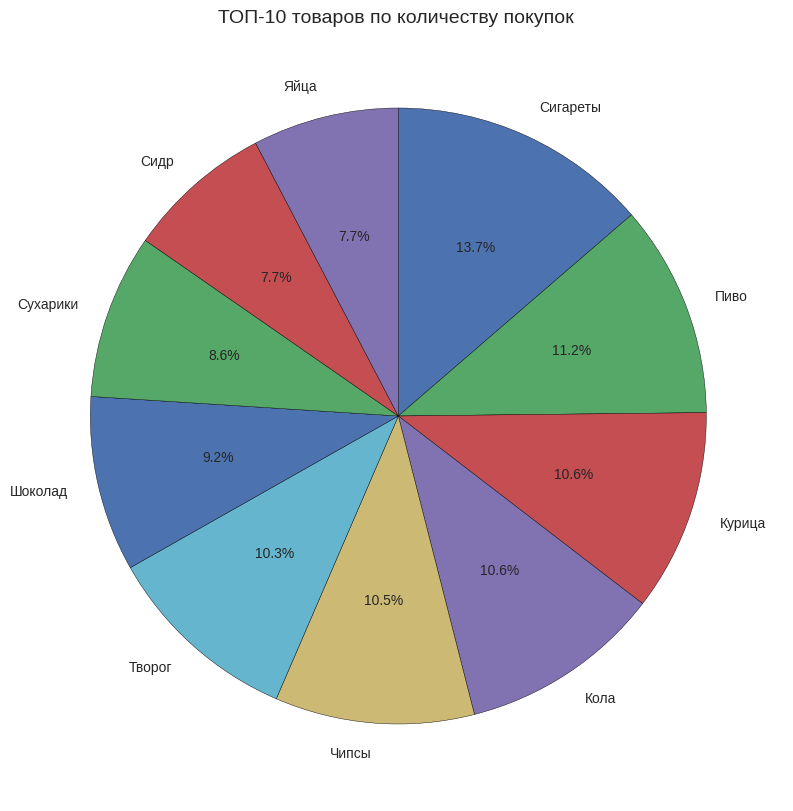

In [265]:
# ============================================
# Круговая диаграмма ТОП‑10 товаров по количеству покупок
# ============================================

# Считаем количество покупок каждого товара
top10_count = df['product'].value_counts().head(10)

plt.figure(figsize=(10, 10))

plt.pie(
    top10_count.values,
    labels=top10_count.index,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    wedgeprops={'edgecolor': 'black'}
)

plt.title("ТОП‑10 товаров по количеству покупок ", fontsize=14)
plt.show()


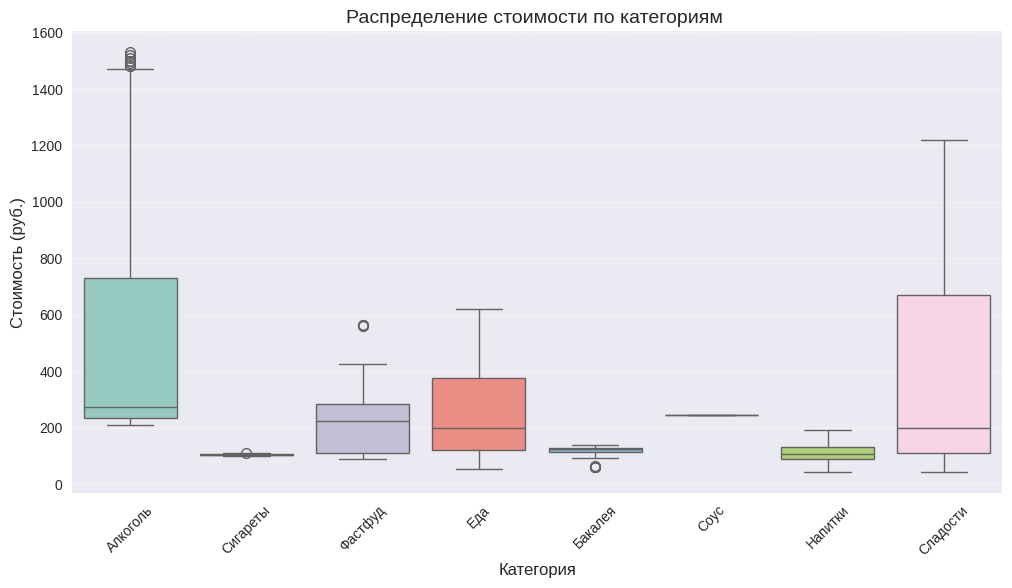

In [266]:
# ============================================
# Boxplot стоимости по категориям
# ============================================

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='category',
    y='price',
    palette='Set3'
)

plt.xlabel("Категория", fontsize=12)
plt.ylabel("Стоимость (руб.)", fontsize=12)
plt.title("Распределение стоимости по категориям ", fontsize=14)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


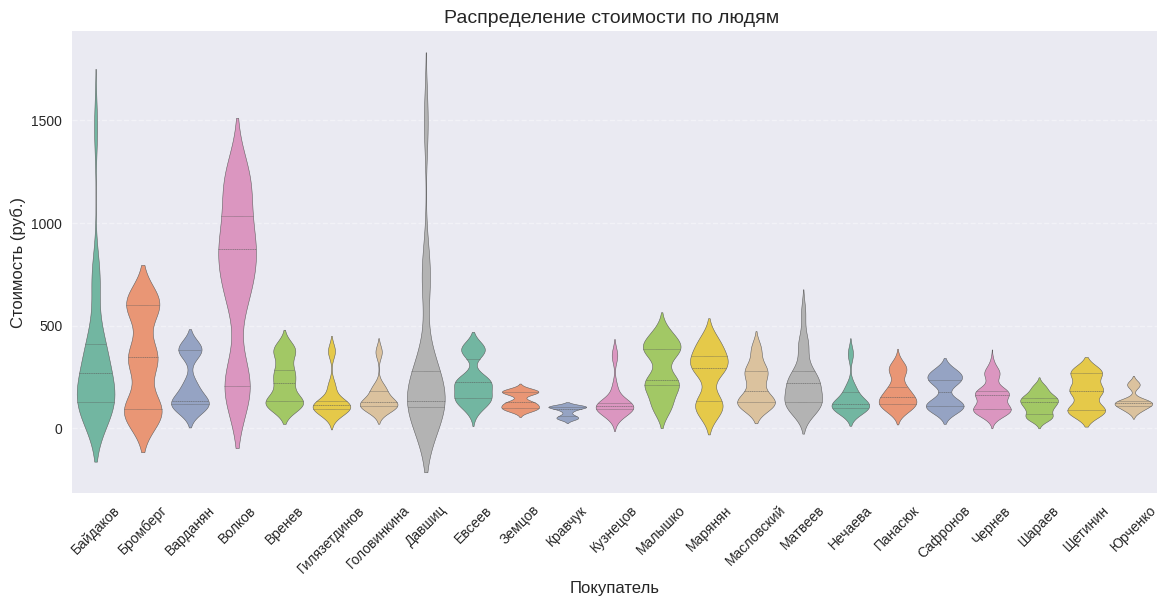

In [267]:
# ============================================
# Violinplot стоимости по людям
# ============================================

plt.figure(figsize=(14, 6))

sns.violinplot(
    data=df,
    x='name',
    y='price',
    palette='Set2',
    inner='quartile'   # показывает медиану и квартили
)

plt.xlabel("Покупатель", fontsize=12)
plt.ylabel("Стоимость (руб.)", fontsize=12)
plt.title("Распределение стоимости по людям ", fontsize=14)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()


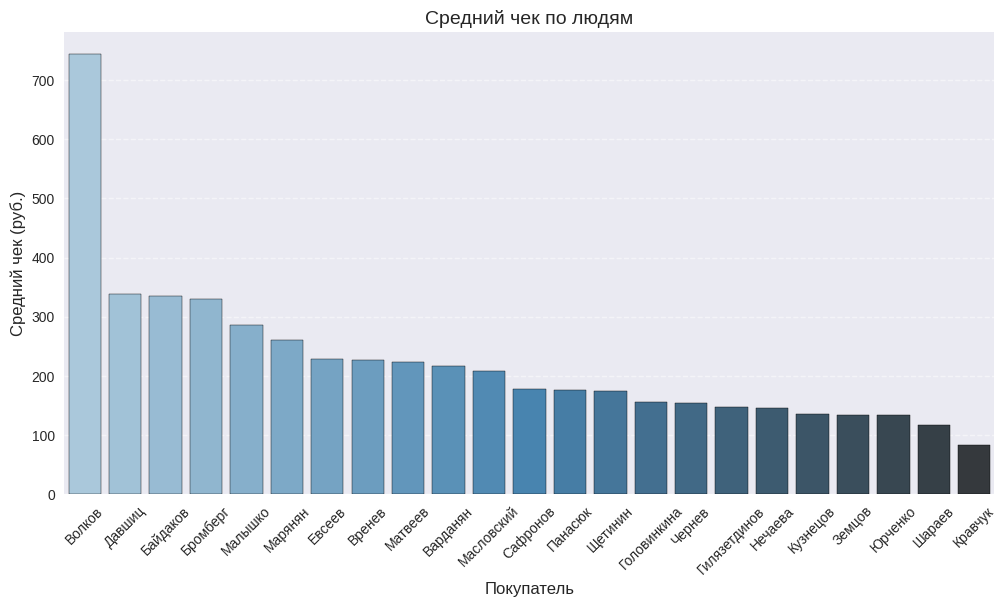

In [268]:
# ============================================
# Barplot среднего чека по людям
# ============================================

# Средний чек по каждому человеку
avg_check = df.groupby('name')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=avg_check.index,
    y=avg_check.values,
    palette='Blues_d',
    edgecolor='black'
)

plt.xlabel("Покупатель", fontsize=12)
plt.ylabel("Средний чек (руб.)", fontsize=12)
plt.title("Средний чек по людям", fontsize=14)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


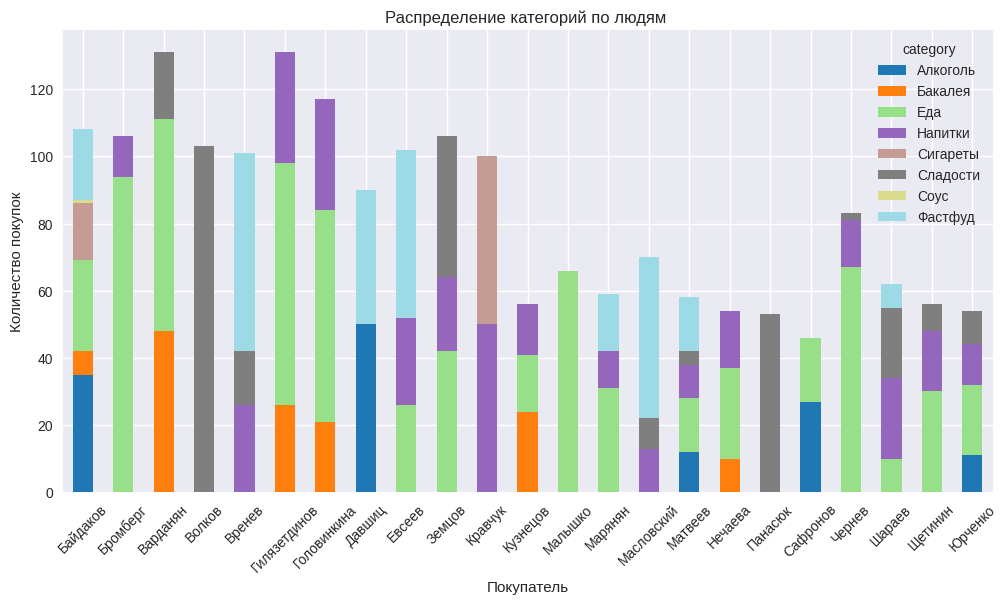

In [269]:
# ============================================
# Сложенная диаграмма: Люди × Категории
# ============================================


df_filtered = df[~(
    ((df['name'] == 'Сафронов') | (df['name'] == 'Давшиц')) &
    (df['category'].str.lower() == 'сигареты')
)]

# Группировка
stack = df_filtered.groupby(['name', 'category']).size().unstack(fill_value=0)

# Построение графика
stack.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')

plt.title("Распределение категорий по людям ")
plt.xlabel("Покупатель")
plt.ylabel("Количество покупок")
plt.xticks(rotation=45)

plt.show()


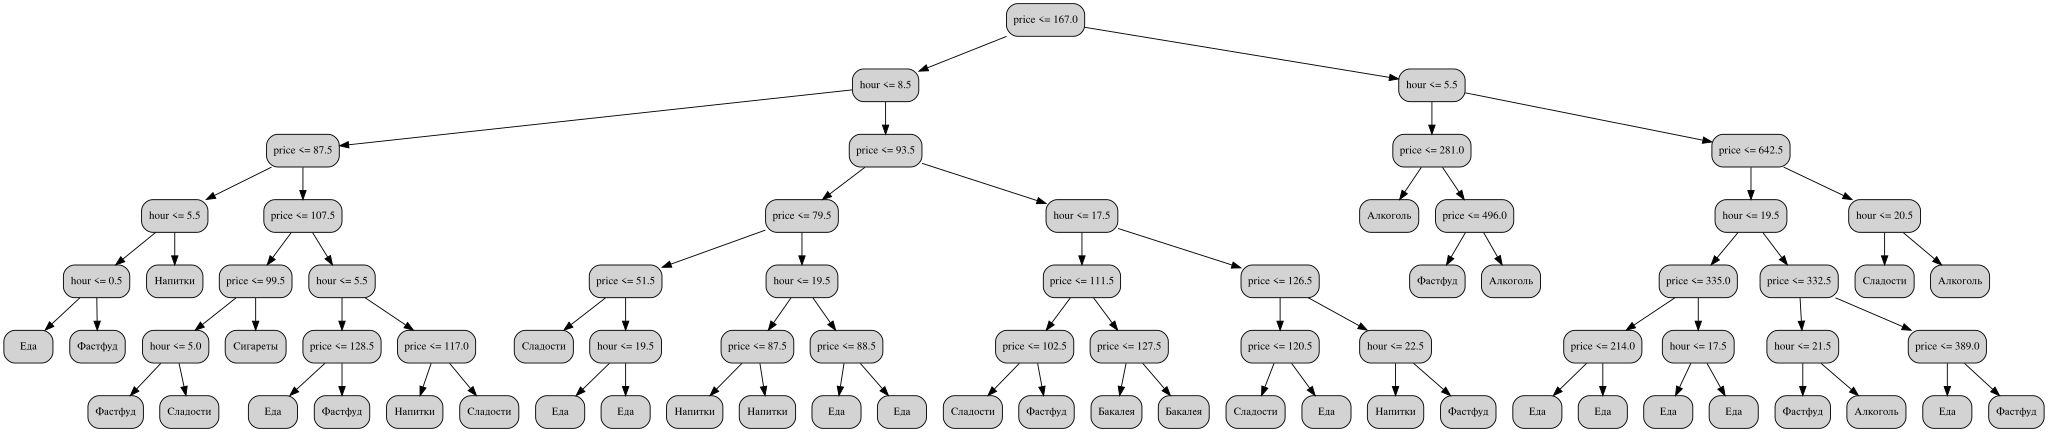

In [270]:
from sklearn.tree import DecisionTreeClassifier, _tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import graphviz
import pandas as pd

# --- Подготовка данных ---
df['time'] = pd.to_datetime(df['time'], format='%H:%M')
df['hour'] = df['time'].dt.hour

le_cat = LabelEncoder()
df['category_encoded'] = le_cat.fit_transform(df['category'])

X = df[['price', 'hour']]
y = df['category_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

clf = DecisionTreeClassifier(max_depth=6, random_state=42)
clf.fit(X_train, y_train)

tree = clf.tree_
feature_names = X.columns

dot = graphviz.Digraph(format='png')   # ✅ формат PNG
dot.attr('node', shape='box', style='filled,rounded', fontsize='12')

def recurse(node_id):
    # Лист
    if tree.children_left[node_id] == _tree.TREE_LEAF:
        class_id = tree.value[node_id].argmax()
        label = le_cat.classes_[class_id]
        dot.node(str(node_id), label)
        return

    # Узел
    feature = feature_names[tree.feature[node_id]]
    threshold = tree.threshold[node_id]
    label = f"{feature} <= {threshold:.1f}"
    dot.node(str(node_id), label)

    # Левый
    left = tree.children_left[node_id]
    dot.edge(str(node_id), str(left))
    recurse(left)

    # Правый
    right = tree.children_right[node_id]
    dot.edge(str(node_id), str(right))
    recurse(right)

recurse(0)

# ✅ Сохранение PNG
dot.render("decision_tree_clean", cleanup=True)

dot